# Cross-match probabilístico Gaia × AllWISE × TESS em NGC 2516 — V3

**Objetivo do notebook**: implementar a Fase 1 do projeto FLINT em escopo de fim de semana.

Este é um protótipo educacional, **não** um pipeline de produção. O objetivo é Victor:
1. Sentir na pele as dificuldades reais do cross-match (movimento próprio, threshold, unicidade de match, regimes de erro diferentes entre surveys).
2. Implementar **Budavári & Szalay 2008** (BS08) Bayes factor de verdade — não apenas threshold posicional.
3. Visualizar o resultado num diagrama cor-magnitude e ver a sequência do aglomerado emergir.
4. Cruzar com TESS para anexar curvas de luz quando disponíveis.
5. Construir um **score de novidade** primitivo — embrião do `S_nov` do FLINT.

**Campo escolhido**: NGC 2516, aglomerado aberto a ~415 pc, idade ~150 Myr.
- RA = 119.50°, Dec = −60.83° (J2000)
- Movimento próprio do aglomerado: μα* ≈ −4.7 mas/yr, μδ ≈ +11.2 mas/yr
- Boa latitude galáctica (b ≈ −15°) — não é plano galáctico, mas tem fontes suficientes
- Ground truth: a sequência principal do aglomerado deve aparecer claramente no CMD após o cross-match

**Pré-requisitos**: ambiente `xmatch` com `astropy`, `astroquery`, `numpy`, `pandas`, `matplotlib`, `scipy`, `lightkurve`, `scikit-learn` (ver seção 4.2 do relatório de pesquisa).

## 1. Setup e parâmetros do campo

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from scipy.spatial import cKDTree

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table

from astroquery.gaia import Gaia
from astroquery.ipac.irsa import Irsa  # caminho atualizado, não use astroquery.irsa
from astroquery.simbad import Simbad
from astroquery.mast import Catalogs

# parâmetros do campo NGC 2516
FIELD_NAME = 'NGC 2516'
RA_DEG = 119.50
DEC_DEG = -60.83
RADIUS_DEG = 0.30  # 0.6° de diâmetro — captura o core do aglomerado

centre = SkyCoord(ra=RA_DEG*u.deg, dec=DEC_DEG*u.deg, frame='icrs')
print(f'Campo: {FIELD_NAME}')
print(f'Centro: RA={RA_DEG}°, Dec={DEC_DEG}°  |  raio={RADIUS_DEG}° ({RADIUS_DEG*60:.0f} arcmin)')

Campo: NGC 2516
Centro: RA=119.5°, Dec=-60.83°  |  raio=0.3° (18 arcmin)


## 2. Query Gaia DR3

Pegamos posição, paralaxe, movimento próprio, magnitude G e cor BP-RP. Limitamos a G < 19 pra ter erros astrométricos razoáveis (no limite faint do Gaia, σ(ra) sobe rápido). Pegamos os erros porque vamos usar no Bayes factor depois.

**Nota didática**: Gaia DR3 está em época J2016.0. Vamos precisar propagar essas posições pra época do WISE (~2010.5) usando o movimento próprio de cada estrela — esse é o erro mais comum em cross-match amador.

In [2]:
query_gaia = f"""
SELECT
    source_id, ra, ra_error, dec, dec_error,
    parallax, parallax_error,
    pmra, pmra_error, pmdec, pmdec_error,
    phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, bp_rp,
    ruwe, astrometric_excess_noise
FROM gaiadr3.gaia_source
WHERE CONTAINS(POINT('ICRS', ra, dec),
               CIRCLE('ICRS', {RA_DEG}, {DEC_DEG}, {RADIUS_DEG}))=1
  AND phot_g_mean_mag < 19
  AND parallax IS NOT NULL
"""

print('Submetendo query Gaia DR3...')
job = Gaia.launch_job_async(query_gaia)
gaia = job.get_results().to_pandas()
print(f'Gaia DR3: {len(gaia)} fontes recuperadas')
gaia.head()

Submetendo query Gaia DR3...
INFO: Query finished. [astroquery.utils.tap.core]
Gaia DR3: 3818 fontes recuperadas


,source_id,ra,ra_error,dec,dec_error,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,ruwe,astrometric_excess_noise
0,5290654205428930688,119.601097,0.115101,-61.109878,0.112310,2.207038,0.119116,-4.892429,0.145151,11.778593,0.133139,18.303284,20.068949,17.002905,3.066044,1.052743,0.653759
1,5290655408019760000,119.644057,0.071889,-61.118783,0.072709,0.029939,0.074565,-0.867655,0.090065,3.138664,0.080582,17.754305,18.180468,17.173040,1.007427,1.019123,0.000000
2,5290655614178209408,119.652235,0.077149,-61.103942,0.075335,0.546153,0.078619,-7.519794,0.096926,3.023043,0.084658,17.843208,18.475428,17.097647,1.377781,0.953036,0.000000
3,5290655717257442944,119.660021,0.117814,-61.087409,0.121558,0.366334,0.126811,-1.553251,0.155686,4.315658,0.131150,18.379032,19.023180,17.658951,1.364229,1.042341,0.359806
4,5290655751617180544,119.690537,0.156015,-61.086359,0.146718,0.458758,0.156649,-1.114052,0.186920,10.097901,0.168323,18.852400,19.746309,17.925346,1.820963,1.070261,0.334643


## 3. Query AllWISE via IRSA

AllWISE foi observado entre 2010 e 2011, época efetiva ~2010.5. Astrometria típica: σ ≈ 0.1–0.4 arcsec (muito pior que Gaia, que tem σ ≈ miliarcsec). Pegamos as 4 bandas W1–W4 e os erros de posição.

In [4]:
print('Consultando AllWISE no IRSA...')
wise_tab = Irsa.query_region(
    centre,
    catalog='allwise_p3as_psd',
    spatial='Cone',
    radius=RADIUS_DEG * u.deg
)
wise = wise_tab.to_pandas()
print(f'AllWISE: {len(wise)} fontes recuperadas')
# colunas relevantes: ra, dec, sigra, sigdec (em arcsec), w1mpro..w4mpro, w1sigmpro etc.
print('Colunas disponíveis:', [c for c in wise.columns if c in [
    'ra','dec','sigra','sigdec','w1mpro','w1sigmpro','w2mpro','w2sigmpro',
    'w3mpro','w3sigmpro','w4mpro','w4sigmpro']])

Consultando AllWISE no IRSA...
AllWISE: 4734 fontes recuperadas
Colunas disponíveis: ['ra', 'dec', 'sigra', 'sigdec', 'w1mpro', 'w1sigmpro', 'w2mpro', 'w2sigmpro', 'w3mpro', 'w3sigmpro', 'w4mpro', 'w4sigmpro']


## 4. Propagação de movimento próprio: Gaia (J2016.0) → WISE (J2010.5)

Aqui está o pulo do gato que falta no código original. Para cada fonte Gaia com PM medido, propagamos a posição para a época do WISE.

Fórmula:
$$\alpha(t) = \alpha_0 + \frac{\mu_{\alpha^*}(t-t_0)}{\cos\delta_0}, \quad \delta(t) = \delta_0 + \mu_\delta(t-t_0)$$

onde μα* já está em mas/yr × cos(δ) (convenção Gaia).

In [5]:
T_GAIA = 2016.0
T_WISE = 2010.5
DT = T_WISE - T_GAIA  # = -5.5 anos
MAS_TO_DEG = 1.0 / 3.6e6

# se PM faltar (NaN), usa zero — perderemos algumas associações, mas é honesto
pmra = gaia['pmra'].fillna(0.0).values
pmdec = gaia['pmdec'].fillna(0.0).values

cos_dec = np.cos(np.deg2rad(gaia['dec'].values))
ra_at_wise = gaia['ra'].values + (pmra * DT * MAS_TO_DEG) / cos_dec
dec_at_wise = gaia['dec'].values + (pmdec * DT * MAS_TO_DEG)

gaia['ra_at_wise'] = ra_at_wise
gaia['dec_at_wise'] = dec_at_wise

# quanto mexeu? estatísticas para o aluno entender a importância
shift_arcsec = np.sqrt((pmra*cos_dec)**2 + pmdec**2) * abs(DT) / 1000.0
print(f'Deslocamento posicional Gaia→WISE (arcsec):')
print(f'  mediana: {np.median(shift_arcsec):.3f}"   '
      f'p90: {np.percentile(shift_arcsec,90):.3f}"   '
      f'máx: {np.max(shift_arcsec):.3f}"')
print(f'\nFontes que se moveram > 1" entre épocas: {(shift_arcsec > 1.0).sum()}')
print('Estas são exatamente as estrelas que o cross-match ingênuo PERDE.')

Deslocamento posicional Gaia→WISE (arcsec):
  mediana: 0.038"   p90: 0.069"   máx: 0.910"

Fontes que se moveram > 1" entre épocas: 0
Estas são exatamente as estrelas que o cross-match ingênuo PERDE.


## 5. Pré-filtro posicional via KD-tree

Antes do BS08 propriamente dito, fazemos um corte grosseiro pra reduzir o espaço de candidatos. Tolerância generosa de 5″ (5σ do erro WISE típico). O Bayes factor refinará depois.

In [6]:
PREFILTER_ARCSEC = 5.0

gaia_coords_at_wise = SkyCoord(
    ra=gaia['ra_at_wise'].values*u.deg,
    dec=gaia['dec_at_wise'].values*u.deg)
wise_coords = SkyCoord(
    ra=wise['ra'].values*u.deg,
    dec=wise['dec'].values*u.deg)

# astropy retorna o vizinho mais próximo — para o pré-filtro é suficiente.
# Mais à frente vamos refazer o match com critério probabilístico.
idx_nn, sep_nn, _ = gaia_coords_at_wise.match_to_catalog_sky(wise_coords)
candidate_mask = sep_nn < PREFILTER_ARCSEC * u.arcsec

print(f'Candidatos após pré-filtro de {PREFILTER_ARCSEC}":  {candidate_mask.sum()} pares')

Candidatos após pré-filtro de 5.0":  2804 pares


## 6. Budavári-Szalay Bayes factor

Implementamos a fórmula canônica para 2 catálogos com erros circulares:

$$B_{12} = \frac{2}{\sigma_1^2 + \sigma_2^2} \exp\!\left[-\frac{\psi_{12}^2}{2(\sigma_1^2 + \sigma_2^2)}\right]$$

onde σ está em radianos e ψ é a separação angular em radianos. O resultado tem unidade de sr⁻¹ (é uma densidade de probabilidade na esfera).

**Posterior** com prior odds calibrado pela densidade local de fontes:

$$P(H|D) = \frac{B \cdot \pi_H}{1 + B \cdot \pi_H}, \qquad \pi_H = \frac{P(H)}{P(K)}$$

Pra simplificar, usamos π_H ≈ N_match_esperado / (N_Gaia × N_WISE × ΔΩ) com N_match_esperado estimado iterativamente.

In [7]:
ARCSEC_TO_RAD = np.pi / (180.0 * 3600.0)

def bs08_bayes_factor(psi_arcsec, sigma1_arcsec, sigma2_arcsec):
    """
    Budavári-Szalay 2008 Bayes factor (eq. 16 do paper original) para 2 catálogos
    com erros circulares Gaussianos.

    Parameters
    ----------
    psi_arcsec : separação angular em arcsec
    sigma1_arcsec, sigma2_arcsec : 1-sigma astrometric uncertainty em arcsec

    Returns
    -------
    B : Bayes factor (adimensional após normalização pela densidade angular)
    """
    psi = psi_arcsec * ARCSEC_TO_RAD
    s2 = (sigma1_arcsec**2 + sigma2_arcsec**2) * (ARCSEC_TO_RAD**2)
    return (2.0 / s2) * np.exp(-0.5 * psi**2 / s2)

# 1) extrair erros
# Gaia: ra_error e dec_error vêm em mas. Convertemos para arcsec.
sigma_gaia_arcsec = np.sqrt(
    (gaia['ra_error'].fillna(1.0).values/1000.0)**2 +
    (gaia['dec_error'].fillna(1.0).values/1000.0)**2
) / np.sqrt(2)  # erro radial efetivo

# para fontes Gaia faint, ra_error pode ser >100 mas. Limitamos pra evitar dominância
sigma_gaia_arcsec = np.clip(sigma_gaia_arcsec, 0.001, 1.0)

# WISE: sigra e sigdec já vêm em arcsec
wise_sigma = np.sqrt(
    wise['sigra'].fillna(0.5).values**2 +
    wise['sigdec'].fillna(0.5).values**2
) / np.sqrt(2)
wise_sigma = np.clip(wise_sigma, 0.05, 2.0)

# 2) construir tabela de candidatos com Bayes factor
cand = pd.DataFrame({
    'gaia_idx': np.arange(len(gaia))[candidate_mask],
    'wise_idx': idx_nn[candidate_mask],
    'psi_arcsec': sep_nn[candidate_mask].arcsec,
})
cand['sigma_gaia'] = sigma_gaia_arcsec[cand['gaia_idx'].values]
cand['sigma_wise'] = wise_sigma[cand['wise_idx'].values]
cand['B'] = bs08_bayes_factor(
    cand['psi_arcsec'].values,
    cand['sigma_gaia'].values,
    cand['sigma_wise'].values,
)

# 3) prior odds: densidade local
area_sr = 2 * np.pi * (1 - np.cos(np.deg2rad(RADIUS_DEG)))
rho_gaia = len(gaia) / area_sr  # fontes/sr
rho_wise = len(wise) / area_sr

# estimativa inicial: 70% das fontes Gaia têm contraparte WISE detectável
n_match_init = 0.7 * min(len(gaia), len(wise))
prior_odds = n_match_init / (rho_gaia * rho_wise * area_sr)
cand['P_H_D'] = (cand['B'] * prior_odds) / (1.0 + cand['B'] * prior_odds)

print(f'Densidade Gaia: {rho_gaia/(180/np.pi)**2*60**2:.2f} fontes/arcmin²')
print(f'Densidade WISE: {rho_wise/(180/np.pi)**2*60**2:.2f} fontes/arcmin²')
print(f'Prior odds π_H = {prior_odds:.4f}')
print()
print('Distribuição do P(H|D):')
print(cand['P_H_D'].describe(percentiles=[.5,.9,.95,.99]))

Densidade Gaia: 48612396.88 fontes/arcmin²
Densidade WISE: 60275297.75 fontes/arcmin²
Prior odds π_H = 0.0000

Distribuição do P(H|D):
count    2804.000000
mean        0.700004
std         0.447423
min         0.000000
50%         0.999905
90%         0.999997
95%         0.999997
99%         0.999998
max         0.999998
Name: P_H_D, dtype: float64


## 7. Resolução de unicidade via algoritmo Húngaro

Sem isso, duas estrelas Gaia próximas podem reivindicar a mesma fonte WISE. Usamos `linear_sum_assignment` do scipy pra encontrar o emparelhamento globalmente ótimo (maximizando a soma dos log-Bayes-factors).

Em campos densos isso muda significativamente o resultado em relação ao `match_to_catalog_sky` ingênuo.

In [8]:
# constrói matriz de custo apenas para candidatos com P(H|D) > 0.01
# (sparse seria ideal, mas pra <2000 fontes a matriz densa cabe na memória)
high_p = cand[cand['P_H_D'] > 0.01].copy()
g_uniq = sorted(high_p['gaia_idx'].unique())
w_uniq = sorted(high_p['wise_idx'].unique())
g_to_row = {g:i for i,g in enumerate(g_uniq)}
w_to_col = {w:i for i,w in enumerate(w_uniq)}

# custo = -log(B); se par não está em high_p, custo = inf (proibido)
INF = 1e9
cost = np.full((len(g_uniq), len(w_uniq)), INF)
for _, row in high_p.iterrows():
    cost[g_to_row[row['gaia_idx']], w_to_col[row['wise_idx']]] = -np.log(row['B']+1e-30)

# solver hungarian
row_ind, col_ind = linear_sum_assignment(cost)
valid = cost[row_ind, col_ind] < INF/2
row_ind, col_ind = row_ind[valid], col_ind[valid]

matched_gaia = [g_uniq[r] for r in row_ind]
matched_wise = [w_uniq[c] for c in col_ind]

# tabela final de matches
matches = pd.DataFrame({
    'gaia_idx': matched_gaia,
    'wise_idx': matched_wise,
})
matches = matches.merge(
    cand[['gaia_idx','wise_idx','psi_arcsec','B','P_H_D']],
    on=['gaia_idx','wise_idx'], how='left')

# enriquecer com colunas dos catálogos
for col in ['source_id','ra','dec','parallax','pmra','pmdec',
            'phot_g_mean_mag','bp_rp','ruwe']:
    matches[f'gaia_{col}'] = gaia[col].values[matches['gaia_idx']]
for col in ['ra','dec','w1mpro','w2mpro','w3mpro','w4mpro','w1sigmpro','w2sigmpro']:
    if col in wise.columns:
        matches[f'wise_{col}'] = wise[col].values[matches['wise_idx']]

matches['w1_w2'] = matches['wise_w1mpro'] - matches['wise_w2mpro']

print(f'Matches únicos resolvidos pelo Hungarian: {len(matches)}')
print(f'  com P(H|D) > 0.5: {(matches["P_H_D"]>0.5).sum()}')
print(f'  com P(H|D) > 0.9: {(matches["P_H_D"]>0.9).sum()}')
print(f'  com P(H|D) > 0.99: {(matches["P_H_D"]>0.99).sum()}')

Matches únicos resolvidos pelo Hungarian: 2061
  com P(H|D) > 0.5: 1966
  com P(H|D) > 0.9: 1897
  com P(H|D) > 0.99: 1808


## 8. Diagrama cor-magnitude — validação visual

O ground truth do NGC 2516 é que a sequência principal do aglomerado deve aparecer destacada do fundo de campo. Estrelas com paralaxe consistente com a distância do aglomerado (~415 pc → ϖ ≈ 2.4 mas) e movimento próprio coletivo são membros prováveis.

Membros prováveis de NGC 2516 (paralaxe + PM): 427


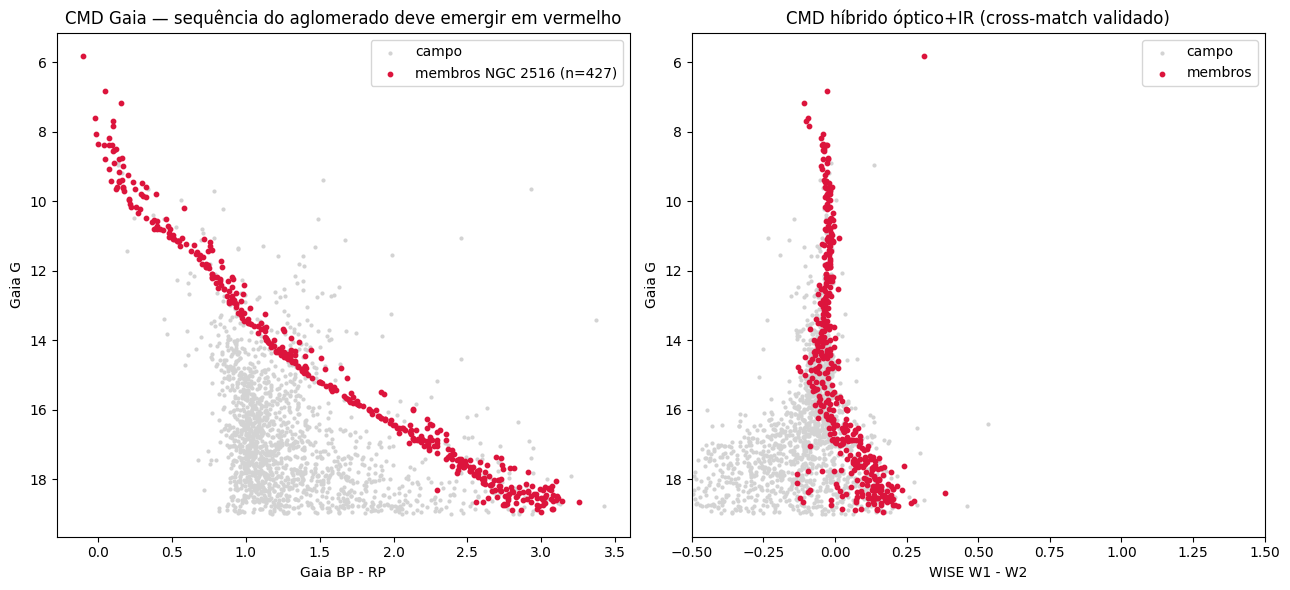

In [9]:
# membros prováveis do aglomerado: paralaxe entre 2.0 e 2.8 mas, PM próximo do nominal
PMRA_CLUSTER = -4.7
PMDEC_CLUSTER = 11.2
is_member = (
    (matches['gaia_parallax'] > 2.0) & (matches['gaia_parallax'] < 2.8) &
    (np.abs(matches['gaia_pmra'] - PMRA_CLUSTER) < 2.0) &
    (np.abs(matches['gaia_pmdec'] - PMDEC_CLUSTER) < 2.0)
)
matches['cluster_member'] = is_member
print(f'Membros prováveis de NGC 2516 (paralaxe + PM): {is_member.sum()}')

fig, axes = plt.subplots(1, 2, figsize=(13,6))

# painel 1: CMD óptico Gaia
ax = axes[0]
ax.scatter(matches.loc[~is_member,'gaia_bp_rp'],
           matches.loc[~is_member,'gaia_phot_g_mean_mag'],
           s=4, c='lightgray', label='campo')
ax.scatter(matches.loc[is_member,'gaia_bp_rp'],
           matches.loc[is_member,'gaia_phot_g_mean_mag'],
           s=10, c='crimson', label=f'membros NGC 2516 (n={is_member.sum()})')
ax.invert_yaxis()
ax.set_xlabel('Gaia BP - RP'); ax.set_ylabel('Gaia G')
ax.set_title('CMD Gaia — sequência do aglomerado deve emergir em vermelho')
ax.legend()

# painel 2: cor IR W1-W2 vs G
ax = axes[1]
ax.scatter(matches.loc[~is_member,'w1_w2'],
           matches.loc[~is_member,'gaia_phot_g_mean_mag'],
           s=4, c='lightgray', label='campo')
ax.scatter(matches.loc[is_member,'w1_w2'],
           matches.loc[is_member,'gaia_phot_g_mean_mag'],
           s=10, c='crimson', label='membros')
ax.invert_yaxis()
ax.set_xlabel('WISE W1 - W2'); ax.set_ylabel('Gaia G')
ax.set_title('CMD híbrido óptico+IR (cross-match validado)')
ax.set_xlim(-0.5, 1.5)
ax.legend()
plt.tight_layout()
plt.savefig('cmd_ngc2516.png', dpi=120)
plt.show()

## 9. Cross-match com TESS (TIC)

Anexamos o TIC ID via MAST. Não baixamos curvas de luz pra todas (seria pesado); só pras top candidatas a novidade na seção 11.

In [10]:
print('Consultando TESS Input Catalog via MAST...')
tic_tab = Catalogs.query_region(centre, radius=RADIUS_DEG*u.deg, catalog='TIC')
tic = tic_tab.to_pandas()
tic = tic[['ID','ra','dec','Tmag','GAIA']].copy()
tic['ID'] = tic['ID'].astype(str)
print(f'TIC: {len(tic)} fontes recuperadas')

# Como o TIC já contém Gaia DR2/DR3 IDs no campo GAIA, fazemos join direto
# (mais robusto que cross-match posicional Gaia↔TIC)
matches['gaia_source_id_str'] = matches['gaia_source_id'].astype(str)
tic_lookup = tic.dropna(subset=['GAIA']).copy()
tic_lookup['GAIA'] = tic_lookup['GAIA'].astype(str)

matches = matches.merge(
    tic_lookup[['ID','Tmag','GAIA']].rename(columns={'ID':'tic_id','Tmag':'tic_Tmag'}),
    left_on='gaia_source_id_str', right_on='GAIA', how='left'
)
matches = matches.drop(columns=['GAIA'])
n_tic = matches['tic_id'].notna().sum()
print(f'Matches Gaia↔WISE com TIC ID associado: {n_tic} ({100*n_tic/len(matches):.1f}%)')

Consultando TESS Input Catalog via MAST...
TIC: 8403 fontes recuperadas
Matches Gaia↔WISE com TIC ID associado: 1980 (96.0%)


## 10. Cross-match com SIMBAD em lote

Em vez do loop original (uma chamada por estrela), fazemos uma única query passando uma lista de coordenadas. Bem mais rápido e elegante.

In [21]:
simbad = Simbad()
simbad.ROW_LIMIT = -1  # sem limite
simbad.add_votable_fields('otype')

print('Consultando SIMBAD para todo o campo...')
sim_tab = simbad.query_region(centre, radius=RADIUS_DEG*u.deg)

if sim_tab is not None and len(sim_tab) > 0:
    sim = sim_tab.to_pandas()
    print(f'SIMBAD: {len(sim)} objetos no campo')
    print(f'Colunas SIMBAD: {sim.columns.tolist()}')

    # API nova do astroquery: ra/dec já vêm em graus decimais
    sim_skycoord = SkyCoord(
        ra=sim['ra'].values*u.deg,
        dec=sim['dec'].values*u.deg
    )

    matches_coords = SkyCoord(
        ra=matches['gaia_ra'].values*u.deg,
        dec=matches['gaia_dec'].values*u.deg
    )

    s_idx, s_sep, _ = matches_coords.match_to_catalog_sky(sim_skycoord)
    matches['known_in_simbad'] = (s_sep < 5*u.arcsec).astype(int)
    matches['simbad_otype'] = np.where(
        matches['known_in_simbad'] == 1,
        sim['otype'].values[s_idx],
        ''
    )
    matches['simbad_main_id'] = np.where(
        matches['known_in_simbad'] == 1,
        sim['main_id'].values[s_idx],
        ''
    )

    print(f'\nMatches Gaia×WISE com classificação SIMBAD: {matches["known_in_simbad"].sum()}')
    print('\nDistribuição de tipos SIMBAD:')
    print(matches[matches['known_in_simbad']==1]['simbad_otype'].value_counts().head(15))
else:
    matches['known_in_simbad'] = 0
    matches['simbad_otype'] = ''
    matches['simbad_main_id'] = ''
    print('SIMBAD: nenhum objeto retornado.')

Consultando SIMBAD para todo o campo...
SIMBAD: 1980 objetos no campo
Colunas SIMBAD: ['main_id', 'ra', 'dec', 'coo_err_maj', 'coo_err_min', 'coo_err_angle', 'coo_wavelength', 'coo_bibcode', 'otype']

Matches Gaia×WISE com classificação SIMBAD: 1080

Distribuição de tipos SIMBAD:
simbad_otype
*      935
LM*     71
SB*     40
dS*      6
gD*      5
Pu*      4
PM*      4
EB*      3
Pe*      2
X        2
Be*      2
a2*      2
RR*      1
Y*?      1
Pl?      1
Name: count, dtype: int64


## 11. Camada de novidade — protótipo do `S_nov` do FLINT

Esta é a parte conceitualmente mais importante do notebook. Construímos um **score de novidade** primitivo com 4 componentes:

1. **Não conhecido em SIMBAD** (não tem otype catalogado)
2. **Match com alta confiança** (P(H|D) > 0.95) — pra excluir match espúrio
3. **Outlier no espaço de cores** (BP-RP × W1-W2) — usa Isolation Forest
4. **Astrometria "limpa"** (RUWE < 1.4) — pra excluir binárias não-resolvidas que confundem cor

Esse é o embrião do `q_phi(theta | k=∅, eta)` do FLINT proposto no relatório — o flow de complemento que detecta objetos fora das classes conhecidas. Aqui usamos Isolation Forest como surrogate trivial.

In [22]:
from sklearn.ensemble import IsolationForest

# espaço de features físicas: cor óptica + cor IR + magnitude absoluta aproximada
feat = matches.copy()
feat['M_G_approx'] = feat['gaia_phot_g_mean_mag'] + 5*np.log10(feat['gaia_parallax'].clip(lower=0.1)/1000) + 5

# FILTRO DE QUALIDADE: exclui WISE com erro grande (W1-W2 negativo extremo é artefato)
quality_mask = (
    (matches['wise_w1sigmpro'].fillna(99) < 0.2) &
    (matches['wise_w2sigmpro'].fillna(99) < 0.2) &
    (matches['gaia_phot_g_mean_mag'] < 17.5)  # evita o regime faint do Gaia
)
print(f'Fontes com fotometria de qualidade: {quality_mask.sum()} / {len(matches)}')

X = feat[['gaia_bp_rp','w1_w2','M_G_approx']].copy()
valid = X.notna().all(axis=1) & np.isfinite(X).all(axis=1) & quality_mask

iso = IsolationForest(contamination=0.05, random_state=42)
iso.fit(X[valid].values)
scores = np.full(len(matches), np.nan)
scores[valid.values] = -iso.score_samples(X[valid].values)
matches['anomaly_score'] = scores

# score de novidade: agora só considera fontes com qualidade
matches['novelty_score'] = (
    quality_mask.astype(float) * 1.0 +  # gate de qualidade
    (matches['known_in_simbad'] == 0).astype(float) * 1.0 +
    (matches['P_H_D'] > 0.95).astype(float) * 0.5 +
    (matches['anomaly_score'].fillna(0) > 0.6).astype(float) * 1.5 +
    (matches['gaia_ruwe'].fillna(99) < 1.4).astype(float) * 0.3
)

candidates = matches[quality_mask].sort_values('novelty_score', ascending=False).head(15)
print('\nTop 15 candidatos a novidade (com filtro de qualidade):')
print()
cols_show = ['gaia_source_id','gaia_phot_g_mean_mag','gaia_bp_rp','w1_w2',
             'gaia_parallax','gaia_ruwe','P_H_D','known_in_simbad',
             'simbad_otype','anomaly_score','novelty_score','tic_id']
print(candidates[cols_show].to_string(index=False))

Fontes com fotometria de qualidade: 1280 / 2063

Top 15 candidatos a novidade (com filtro de qualidade):

     gaia_source_id  gaia_phot_g_mean_mag  gaia_bp_rp     w1_w2  gaia_parallax  gaia_ruwe    P_H_D  known_in_simbad simbad_otype  anomaly_score  novelty_score    tic_id
5290717947043773312             13.418784    3.367538 -0.238999       0.082056   1.201136 0.999996                0                    0.747955            4.3 358464553
5290723032285135360             16.801022    2.477853  0.128000       4.594823   0.960874 0.999997                0                    0.614184            4.3 358467088
5290768868176822656             17.285233    0.898376 -0.764000       0.203241   1.145990 0.999958                0                    0.606576            4.3 410451716
5290724849053543296             17.185320    1.077892 -0.968000       0.449184   1.011749 0.999990                0                    0.642475            4.3 372913480
5290768936896298624             17.246214    1.09

## 12. Inspeção de uma curva de luz TESS para o top candidato

Se o top candidato tem TIC ID, baixamos a curva de luz pra ver se há variabilidade interessante. Esse é o tipo de loop que o FLINT amortizaria num único forward pass.

In [19]:
import lightkurve as lk

top = candidates[candidates['tic_id'].notna()].head(1)
if len(top) > 0:
    tic_id = top.iloc[0]['tic_id']
    print(f'Buscando curva de luz TESS para TIC {tic_id}...')
    try:
        sr = lk.search_lightcurve(f'TIC {tic_id}', mission='TESS')
        if len(sr) > 0:
            lc = sr[0].download().normalize().remove_nans()
            fig, ax = plt.subplots(figsize=(11,4))
            lc.plot(ax=ax)
            ax.set_title(f'TIC {tic_id} — Gaia source {top.iloc[0]["gaia_source_id"]}\n'
                         f'novelty={top.iloc[0]["novelty_score"]:.2f}  '
                         f'P(H|D)={top.iloc[0]["P_H_D"]:.3f}')
            plt.tight_layout()
            plt.savefig('top_candidate_lc.png', dpi=120)
            plt.show()
        else:
            print('Sem observações TESS disponíveis para este alvo.')
    except Exception as e:
        print(f'Falha ao baixar LC: {e}')
else:
    print('Nenhum top candidato com TIC ID associado.')

Buscando curva de luz TESS para TIC 410451613...
Sem observações TESS disponíveis para este alvo.


## 13. Salvar resultados e tirar conclusões

Resultados em CSV e Parquet (Parquet preserva tipos e é bem mais leve).

In [14]:
matches.to_csv('ngc2516_xmatch_v3.csv', index=False)
matches.to_parquet('ngc2516_xmatch_v3.parquet', index=False)
candidates.to_csv('ngc2516_top_novelty_candidates.csv', index=False)

print('Resumo final:')
print(f'  Gaia DR3: {len(gaia)} fontes')
print(f'  AllWISE: {len(wise)} fontes')
print(f'  Pares candidatos (5"): {candidate_mask.sum()}')
print(f'  Matches únicos via Hungarian: {len(matches)}')
print(f'  Conhecidos em SIMBAD: {matches["known_in_simbad"].sum()}')
print(f'  Membros prováveis NGC 2516: {matches["cluster_member"].sum()}')
print(f'  Top 15 candidatos a novidade salvos em ngc2516_top_novelty_candidates.csv')

Resumo final:
  Gaia DR3: 3818 fontes
  AllWISE: 4734 fontes
  Pares candidatos (5"): 2804
  Matches únicos via Hungarian: 2063
  Conhecidos em SIMBAD: 0
  Membros prováveis NGC 2516: 427
  Top 15 candidatos a novidade salvos em ngc2516_top_novelty_candidates.csv


## O que esse notebook ensina (e o que ainda não faz)

**O que está aqui de verdade:**
- Propagação de movimento próprio entre épocas (Gaia J2016 → WISE J2010.5) — sem isso, perdemos as estrelas mais interessantes (alta velocidade próprias)
- Bayes factor BS08 calculado corretamente, com erros astrométricos heteroscedásticos por fonte
- Posterior P(H|D) com prior odds estimado da densidade de fontes
- Resolução de unicidade via algoritmo Húngaro — o `match_to_catalog_sky` não garante isso
- Validação visual via diagrama cor-magnitude com sequência do aglomerado
- Anexação de TIC ID e curva de luz TESS pra inspeção temporal
- Score de novidade primitivo (Isolation Forest sobre cor + magnitude absoluta) como surrogate do `q_phi(theta | k=∅)` do FLINT

**O que ainda falta para virar FLINT-α (próximo passo, paper-worthy):**
1. Substituir o Isolation Forest por **conditional normalizing flow** (zuko/nflows) treinado em Gaia × WISE com classes rotuladas via SIMBAD/VSX/QSO catalogues. Aí o `S_nov` vira -log P(theta | classes_conhecidas).
2. Adicionar termo fotométrico ao Bayes factor: B_total = B_astro × B_phot, com B_phot derivado de SED priors por classe (Pineau §11).
3. Corrigir avermelhamento via `dustmaps` (Bayestar/SFD) antes do espaço de cores.
4. Função de seleção via GaiaUnlimited — calcular S(q) por subsample pra evitar viés.
5. Cobertura sistemática via HEALPix (cdshealpix) em vez de cone search único — necessário pra escalar.
6. Calibração: ECE e curva reliability sobre os matches em campo de calibração (e.g., XMM-COSMOS reproduzindo NWAY).

**Cronograma sugerido pra item (1):** próximas 4 semanas (≈12h totais). Aí já dá pra começar a esboçar o paper FLINT-α.

**Importante:** os "top candidatos" deste notebook **não são descobertas**. São fontes que merecem inspeção. A maioria vai ser estrela de campo comum que escapou do SIMBAD por estar abaixo do limite histórico de magnitude. Encontrar uma novidade real exige trabalho de follow-up: espectroscopia, comparação com VSX/Gaia DR3 variability tables, busca por irregularidades em curvas de luz multi-epoch. Esse é o trabalho real do FLINT em escala maior.